# Example: Twiss from phase data (combination and fit)

In [1]:
# In this example twiss estimation is formulated as a fitting problem

# Given a probe location and a range limit to use, construc pairs and zero equations using model matrices and measured phases
# Additionaly sample from combinations (bootstrap) and adds noise to measured phases (mc)
# Added robus loss function and phase pre-filtering

# Global fit formulation is also presented

In [2]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

False


In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [4]:
# Compute reference parameters (frequency, amplitude and phase)

df = pandas.read_pickle('../../virtual_tbt.pkl.gz')

length = 4096
w = Window(length, 'cosine_window', 4.0, dtype=dtype, device=device)

x = Data.from_data(w, torch.tensor(df.X.to_list(), dtype=dtype, device=device))
y = Data.from_data(w, torch.tensor(df.Y.to_list(), dtype=dtype, device=device))

f = Frequency(x)
x.window_remove_mean()
x.window_apply()
f('parabola')
x.reset()
ref_nux, ref_sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
d = Decomposition(x)
result, _ = d.harmonic_sum(ref_nux, w.window, x.data)
_, _, ref_ax, ref_fx = result.T

f = Frequency(y)
y.window_remove_mean()
y.window_apply()
f('parabola')
y.reset()
ref_nuy, ref_sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
d = Decomposition(y)
result, _ = d.harmonic_sum(ref_nuy, w.window, y.data)
_, _, ref_ay, ref_fy = result.T

In [5]:
# Set noise

noise_x = 1.0E-6*(50.0 + 0.0*torch.rand(x.size, dtype=dtype, device=device))
noise_y = 1.0E-6*(50.0 + 0.0*torch.rand(y.size, dtype=dtype, device=device))

nux= 0.536883163, sigma_nux=9.03549041e-07, error_nux=6.37891893e-08

(ax - ref_ax).abs().sum().item()=0.000115393486

(fx - ref_fx).abs().sum().item()=0.0566534677



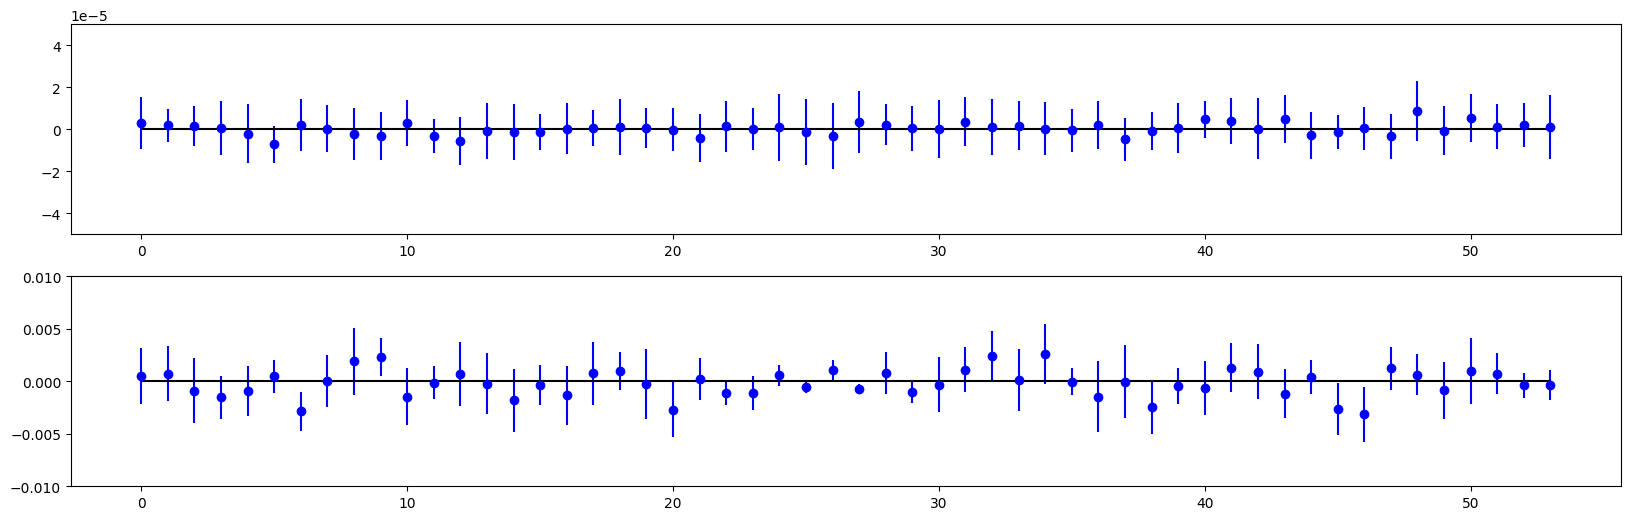

In [6]:
# Compute frequency, amplitude and phase for x plane with noise

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_data(w, x.data[:, :length])
d.add_noise(noise_x)
d.data.copy_(d.work)

# Frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(ref_nux - nux).item():12.9}')
print()

# Amplitude & phase

d = Decomposition(d)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=64, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
print(f'{(ax - ref_ax).abs().sum().item()=:12.9}')
print()

fx, sigma_fx, _ = d.harmonic_phase(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')
print(f'{(fx - ref_fx).abs().sum().item()=:12.9}')
print()

plt.figure(figsize=(20, 3*2))
ax1 = plt.subplot(211)
ax1.errorbar(range(x.size), (ax - ref_ax).cpu().numpy(), yerr=sigma_ax.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, x.size - 1, colors='black')
ax1.set_ylim(-5.0E-5, +5.0E-5)
ax2 = plt.subplot(212)
ax2.errorbar(range(x.size), (fx - ref_fx).cpu().numpy(), yerr=sigma_fx.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, x.size - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)
plt.show()

nuy=  0.57677465, sigma_nuy=9.75034097e-07, error_nuy=1.68631158e-08

(ay - ref_ay).abs().sum().item()=0.00013725325

(fy - ref_fy).abs().sum().item()=0.0613097957



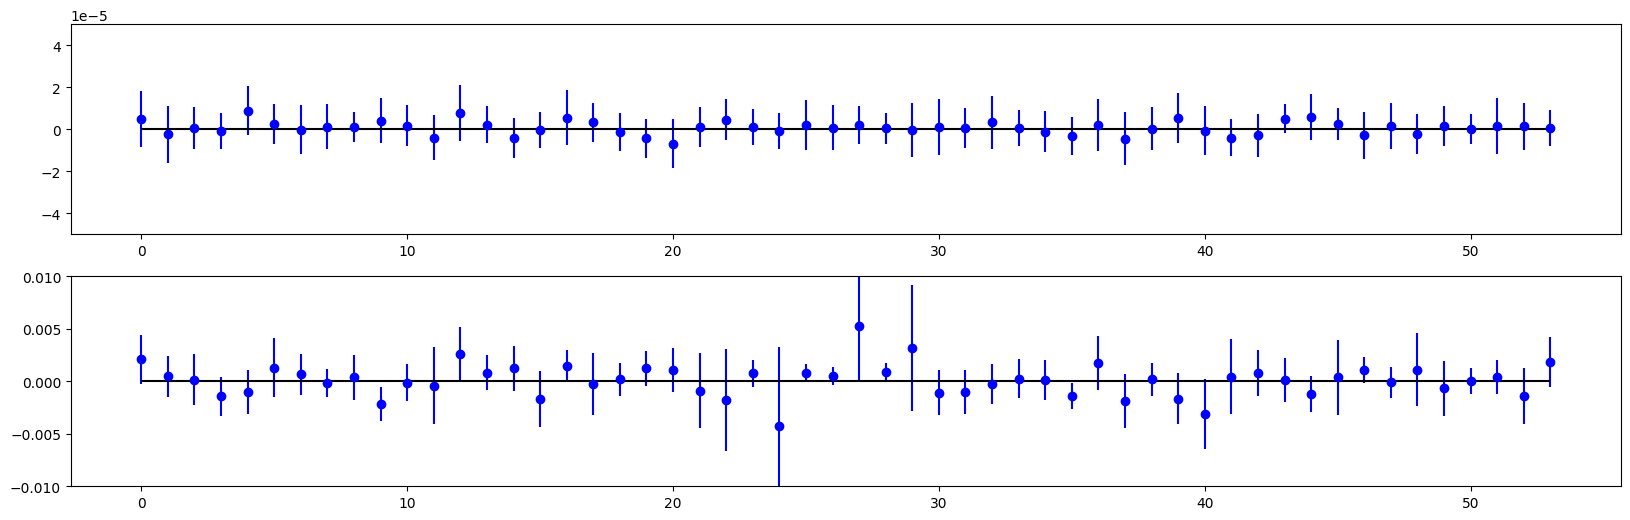

In [7]:
# Compute frequency, amplitude and phase for y plane with noise

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_data(w, y.data[:, :length])
d.add_noise(noise_y)
d.data.copy_(d.work)

# Frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(ref_nuy - nuy).item():12.9}')
print()

# Amplitude & phase

d = Decomposition(d)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=64, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
print(f'{(ay - ref_ay).abs().sum().item()=:12.9}')
print()

fy, sigma_fy, _ = d.harmonic_phase(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')
print(f'{(fy - ref_fy).abs().sum().item()=:12.9}')
print()

plt.figure(figsize=(20, 3*2))
ax1 = plt.subplot(211)
ax1.errorbar(range(y.size), (ay - ref_ay).cpu().numpy(), yerr=sigma_ay.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, y.size - 1, colors='black')
ax1.set_ylim(-5.0E-5, +5.0E-5)
ax2 = plt.subplot(212)
ax2.errorbar(range(y.size), (fy - ref_fy).cpu().numpy(), yerr=sigma_fy.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, y.size - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)
plt.show()

In [8]:
# Set model & table

model = Model(path='../../config.yaml', dtype=dtype, device=device)
table = Table([name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'], nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy, dtype=dtype, device=device)

In [9]:
# Set and compute twiss from phase

twiss = Twiss(model, table, limit=4)
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x')
mask_y = twiss.filter_twiss(plane='y')
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

In [10]:
# Set positions

position = model.time

In [11]:
# Set model twiss

ax_m, bx_m = twiss.model.ax[1:-1].cpu().numpy(), twiss.model.bx[1:-1].cpu().numpy()
ay_m, by_m = twiss.model.ay[1:-1].cpu().numpy(), twiss.model.by[1:-1].cpu().numpy()

In [12]:
# Set twiss from phase

ax, sigma_ax = twiss.ax[1:-1].cpu().numpy(), twiss.sigma_ax[1:-1].cpu().numpy()
bx, sigma_bx = twiss.bx[1:-1].cpu().numpy(), twiss.sigma_bx[1:-1].cpu().numpy()
ay, sigma_ay = twiss.ay[1:-1].cpu().numpy(), twiss.sigma_ay[1:-1].cpu().numpy()
by, sigma_by = twiss.by[1:-1].cpu().numpy(), twiss.sigma_by[1:-1].cpu().numpy()

In [13]:
from pandas import DataFrame

df = DataFrame()
df['BPM'] = twiss.model.name[1:-1]
df['POSITION'] = model.time[1:-1].cpu().numpy()
df['AX'] = ax
df['AX_M'] = ax_m
df['SIGMA_AX'] = sigma_ax
df['ERROR_AX'] = (ax_m - ax)
df['BX'] = bx
df['BX_M'] = bx_m
df['SIGMA_BX'] = sigma_bx
df['ERROR_BX'] = (bx_m - bx)/bx_m
df['DELTA_BX'] = sigma_bx/bx_m
df['AY'] = ay
df['AY_M'] = ay_m
df['SIGMA_AY'] = sigma_ay
df['ERROR_AY'] = (ay_m - ay)
df['BY'] = by
df['BY_M'] = by_m
df['SIGMA_BY'] = sigma_by
df['ERROR_BY'] = (by_m - by)/by_m
df['DELTA_BY'] = sigma_by/by_m

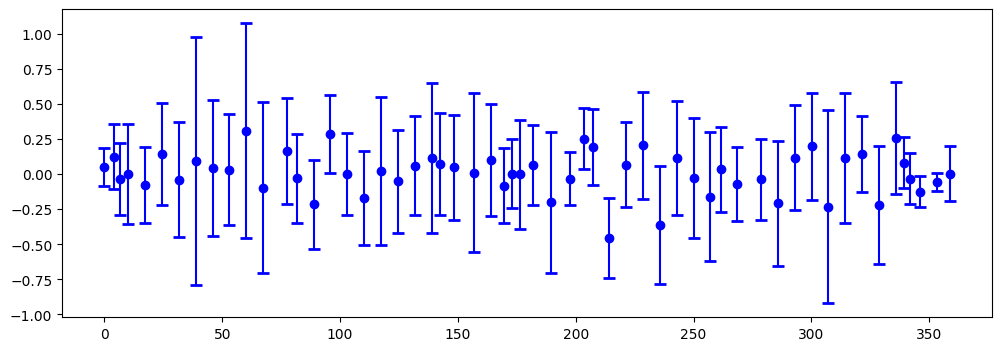

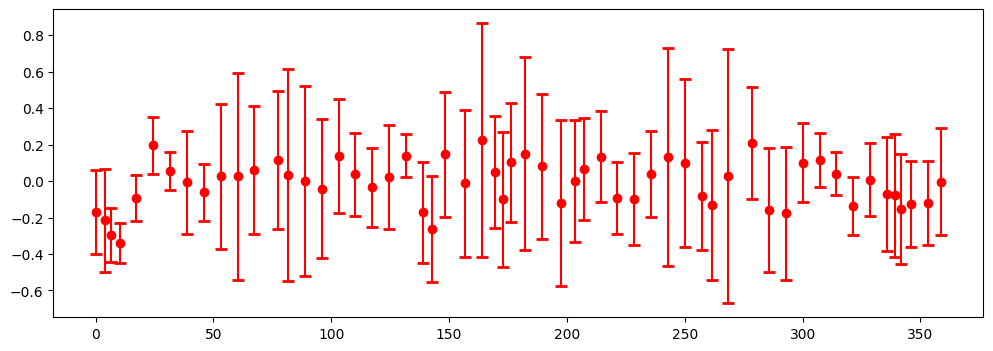

tensor(1.512890710486e-01, dtype=torch.float64)
tensor(1.282074088496e-01, dtype=torch.float64)


In [14]:
# Plot beta beating

from harmonica.statistics import root_mean_square

plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BX'], yerr=100*df['DELTA_BX'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='blue')
plt.show()

plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BY'], yerr=100*df['DELTA_BY'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='red')
plt.show()

print(100*root_mean_square(torch.tensor(df['ERROR_BX'], dtype=dtype)))
print(100*root_mean_square(torch.tensor(df['ERROR_BY'], dtype=dtype)))

In [15]:
output = twiss.get_twiss_from_phase_fit(matrix=model.matrix, limit=4, count=128, log_cosh=True, phase_filter=True, mc_phase=False, verbose=False)

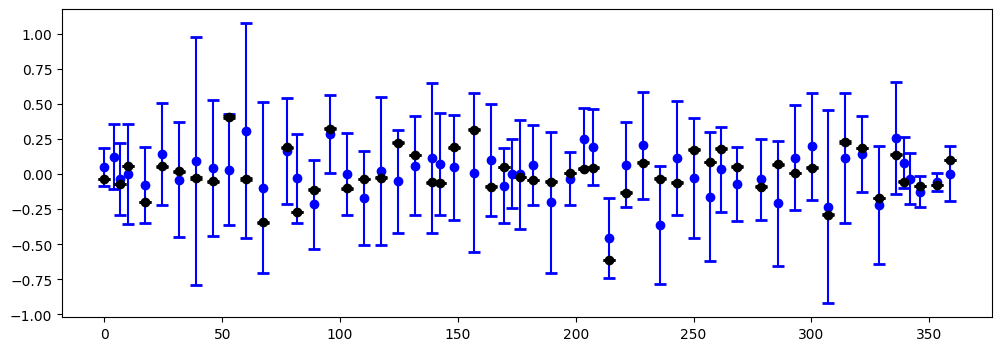

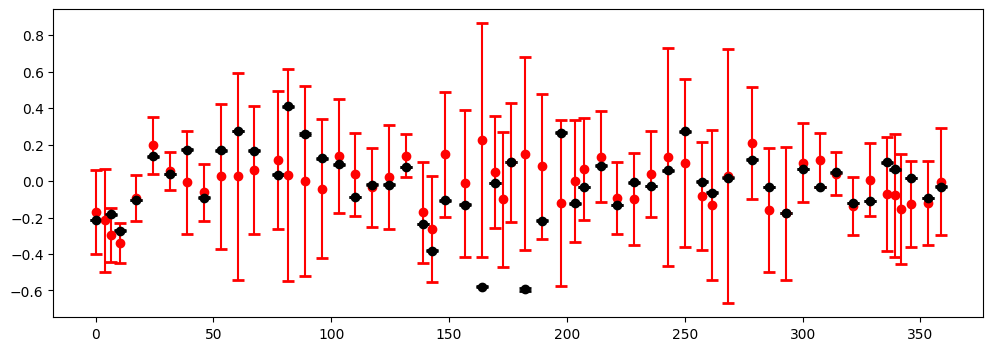

tensor(1.512890710486e-01, dtype=torch.float64)
tensor(1.696427167162e-01, dtype=torch.float64)

tensor(1.282074088496e-01, dtype=torch.float64)
tensor(1.877203138730e-01, dtype=torch.float64)



In [16]:
n11, n33, n21, n43, n13, n31, n14, n41 = output.swapaxes(0, 1)

bx_data = n11**2
by_data = n33**2

bx_value, bx_error = bx_data.mean(-1), bx_data.std(-1)
by_value, by_error = by_data.mean(-1), by_data.std(-1)

bbx = (model.bx[model.monitor_index] - bx_value)/model.bx[model.monitor_index]
ebx = bx_error/model.bx[model.monitor_index]

bby = (model.by[model.monitor_index] - by_value)/model.by[model.monitor_index]
eby = by_error/model.by[model.monitor_index]


plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BX'], yerr=100*df['DELTA_BX'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='blue')
plt.errorbar(model.time[model.monitor_index], 100*bbx, yerr=ebx, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BY'], yerr=100*df['DELTA_BY'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='red')
plt.errorbar(model.time[model.monitor_index], 100*bby, yerr=eby, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

print(100*root_mean_square(torch.tensor(df['ERROR_BX'], dtype=dtype)))
print(100*root_mean_square(bbx))
print()

print(100*root_mean_square(torch.tensor(df['ERROR_BY'], dtype=dtype)))
print(100*root_mean_square(bby))
print()

In [17]:
output = twiss.get_twiss_from_phase_fit(matrix=model.matrix, limit=4, count=128, log_cosh=True, phase_filter=True, mc_phase=True, verbose=False)

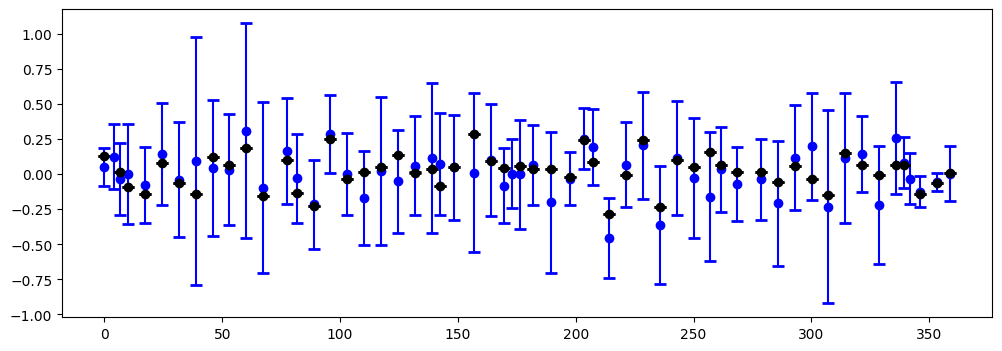

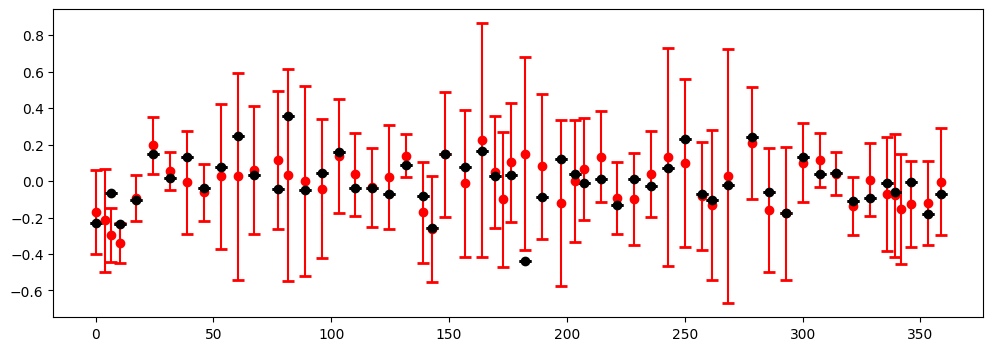

tensor(1.512890710486e-01, dtype=torch.float64)
tensor(1.238543565891e-01, dtype=torch.float64)

tensor(1.282074088496e-01, dtype=torch.float64)
tensor(1.372198923934e-01, dtype=torch.float64)



In [18]:
from harmonica.statistics import trimmed_mean, trimmed_variance

n11, n33, n21, n43, n13, n31, n14, n41 = output.swapaxes(0, 1)

bx_data = n11**2
by_data = n33**2

bx_value, bx_error = torch.vmap(trimmed_mean)(bx_data), torch.vmap(trimmed_variance)(bx_data)
by_value, by_error = torch.vmap(trimmed_mean)(by_data), torch.vmap(trimmed_variance)(by_data)

bbx = (model.bx[model.monitor_index] - bx_value)/model.bx[model.monitor_index]
ebx = bx_error/model.bx[model.monitor_index]

bby = (model.by[model.monitor_index] - by_value)/model.by[model.monitor_index]
eby = by_error/model.by[model.monitor_index]


plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BX'], yerr=100*df['DELTA_BX'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='blue')
plt.errorbar(model.time[model.monitor_index], 100*bbx, yerr=ebx, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BY'], yerr=100*df['DELTA_BY'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='red')
plt.errorbar(model.time[model.monitor_index], 100*bby, yerr=eby, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

print(100*root_mean_square(torch.tensor(df['ERROR_BX'], dtype=dtype)))
print(100*root_mean_square(bbx))
print()

print(100*root_mean_square(torch.tensor(df['ERROR_BY'], dtype=dtype)))
print(100*root_mean_square(bby))
print()

In [19]:
output = twiss.get_twiss_from_phase_fit_global(matrix=model.matrix, limit=4, count=128, log_cosh=True, phase_filter=True, mc_phase=False, verbose=False)

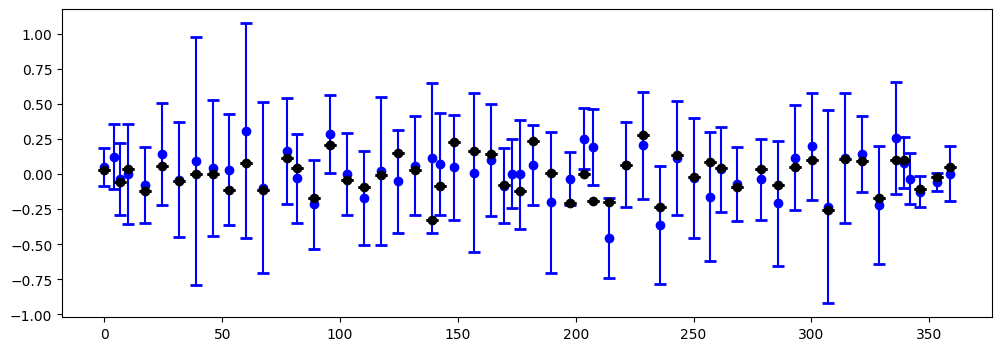

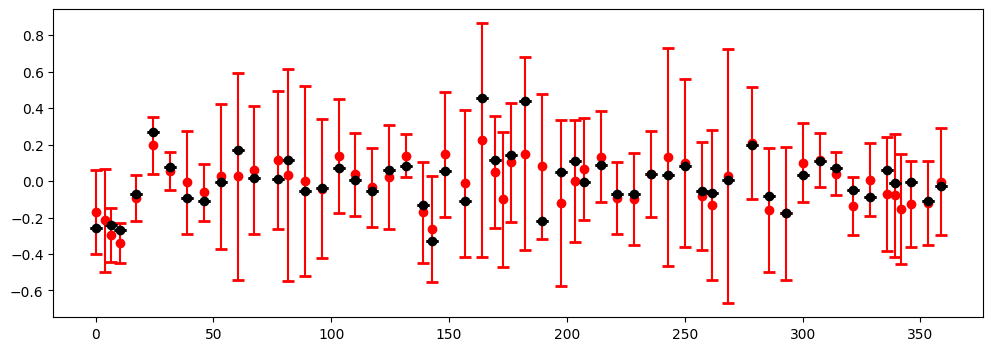

tensor(1.512890710486e-01, dtype=torch.float64)
tensor(1.308198604853e-01, dtype=torch.float64)

tensor(1.282074088496e-01, dtype=torch.float64)
tensor(1.462625677516e-01, dtype=torch.float64)



In [20]:
from harmonica.statistics import trimmed_mean, trimmed_variance

n11, n33, n21, n43, n13, n31, n14, n41 = output.swapaxes(0, 1)

bx_data = n11**2
by_data = n33**2

bx_value, bx_error = torch.vmap(trimmed_mean)(bx_data), torch.vmap(trimmed_variance)(bx_data)
by_value, by_error = torch.vmap(trimmed_mean)(by_data), torch.vmap(trimmed_variance)(by_data)

bbx = (model.bx[model.monitor_index] - bx_value)/model.bx[model.monitor_index]
ebx = bx_error/model.bx[model.monitor_index]

bby = (model.by[model.monitor_index] - by_value)/model.by[model.monitor_index]
eby = by_error/model.by[model.monitor_index]


plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BX'], yerr=100*df['DELTA_BX'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='blue')
plt.errorbar(model.time[model.monitor_index], 100*bbx, yerr=ebx, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BY'], yerr=100*df['DELTA_BY'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='red')
plt.errorbar(model.time[model.monitor_index], 100*bby, yerr=eby, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

print(100*root_mean_square(torch.tensor(df['ERROR_BX'], dtype=dtype)))
print(100*root_mean_square(bbx))
print()

print(100*root_mean_square(torch.tensor(df['ERROR_BY'], dtype=dtype)))
print(100*root_mean_square(bby))
print()

In [21]:
output = twiss.get_twiss_from_phase_fit_global(matrix=model.matrix, limit=4, count=128, log_cosh=True, phase_filter=True, mc_phase=True, verbose=False)

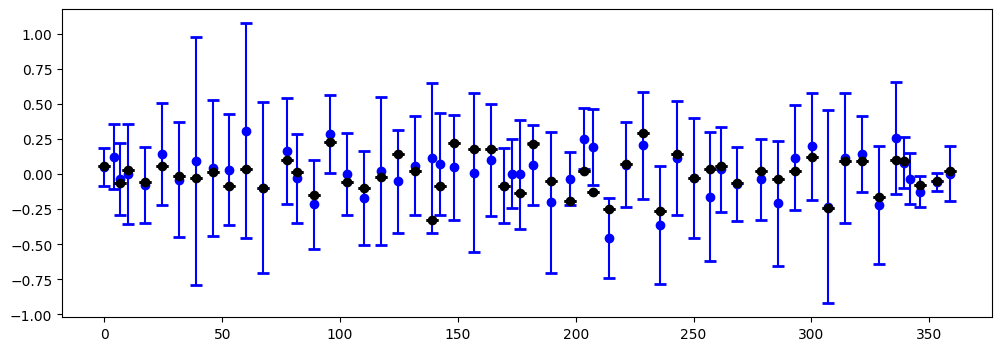

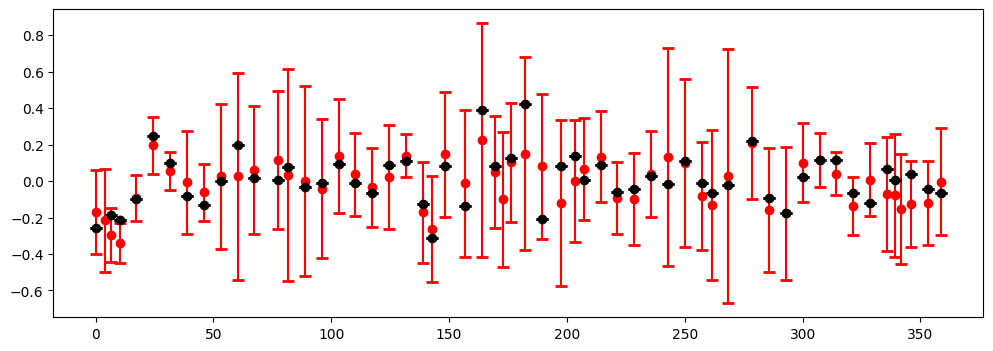

tensor(1.512890710486e-01, dtype=torch.float64)
tensor(1.301947171870e-01, dtype=torch.float64)

tensor(1.282074088496e-01, dtype=torch.float64)
tensor(1.403205909066e-01, dtype=torch.float64)



In [22]:
from harmonica.statistics import trimmed_mean, trimmed_variance

n11, n33, n21, n43, n13, n31, n14, n41 = output.swapaxes(0, 1)

bx_data = n11**2
by_data = n33**2

bx_value, bx_error = torch.vmap(trimmed_mean)(bx_data), torch.vmap(trimmed_variance)(bx_data)
by_value, by_error = torch.vmap(trimmed_mean)(by_data), torch.vmap(trimmed_variance)(by_data)

bbx = (model.bx[model.monitor_index] - bx_value)/model.bx[model.monitor_index]
ebx = bx_error/model.bx[model.monitor_index]

bby = (model.by[model.monitor_index] - by_value)/model.by[model.monitor_index]
eby = by_error/model.by[model.monitor_index]


plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BX'], yerr=100*df['DELTA_BX'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='blue')
plt.errorbar(model.time[model.monitor_index], 100*bbx, yerr=ebx, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

plt.figure(figsize=(12, 4))
plt.errorbar(df['POSITION'], 100*df['ERROR_BY'], yerr=100*df['DELTA_BY'], fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='red')
plt.errorbar(model.time[model.monitor_index], 100*bby, yerr=eby, fmt='o', capsize=4, capthick=2, elinewidth=1.5, color='black')
plt.show()

print(100*root_mean_square(torch.tensor(df['ERROR_BX'], dtype=dtype)))
print(100*root_mean_square(bbx))
print()

print(100*root_mean_square(torch.tensor(df['ERROR_BY'], dtype=dtype)))
print(100*root_mean_square(bby))
print()